<a href="https://colab.research.google.com/github/Kommmi/Qaos/blob/main/01_GQS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Global state and environment-conditioned decomposition

The global state of a multibody system can be written as when focusing on a subsystem $S_a$.

$$
|\Psi_{SE}(t)\rangle
=\sum_{k=1}^{d_S}\sum_{j=1}^{d_E}
\psi_{kj}(t)\,
|s_k^{(a)}\rangle|e_j^{(\neq a)}\rangle.
$$

$$
|\Psi_{SE}(t)\rangle
=
\sum_{j=1}^{d_E}
\sqrt{\lambda_j^{E}(t)}
\,|\chi_j^{S_a}(t)\rangle
|e_j^{(\neq a)}\rangle .
$$
Here,
$$\lambda_j^{E}(t) = \sum_{k}|\psi_{kj}(t)|^2,
\quad
|\chi_j^{S_a}(t)\rangle
=
\frac{1}{\sqrt{\lambda_j^{E}(t)}}
\sum_{k}\psi_{kj}(t)\,|s_k^{(a)}\rangle.$$


### 2. Local state: density matrix

The reduced state of the subsystem is obtained by tracing out the environment:

$$
\rho^{S_a} =
\sum_{j=1}^{d_E}\lambda_j^E
|\chi_j^{S_a}\rangle\langle \chi_j^{S_a}|.
$$


### 3. Local state: geometric quantum state

Rather than viewing the reduced state solely as a density matrix, we adopt the **geometric quantum state (GQS)** representation.

Each conditional pure state defines a point in projective Hilbert space,

$$
|\chi_i^{S_a}\rangle →
\mathbf{Z}_i^{S_a}(t)
=\big[c_1^{(i)}(t):\cdots:c_d^{(i)}(t)\big]
\in\mathbb{C}P^{d_E-1}.
$$

The reduced state is represented as a probability measure,

$$
Q^{S_a}(Z,t)
=\sum_{j=1}^{d_E}\lambda_j^{E}(t)\,
\delta\!\left(Z-\mathbf{Z}_j^{S_a}(t)\right).
$$


The states $\{|\chi_j^{S_a}(t)\rangle\}$ are not generally orthogonal, and the weights $\{\lambda_j^{E}(t)\}$ are not eigenvalues of $\rho^{S_a}(t)$. Within the GQS framework, the pairs $\{\lambda_j^{E}(t),|\chi_j^{S_a}(t)\rangle\}$ define a probability distribution over subsystem pure states. This representation preserves the explicit correspondence between environment configurations and subsystem states


In [1]:
!rm -rf Quantum-Dynamical-Systems
# Clean slate
#!pip uninstall -y gqs
!git clone https://github.com/Kommmi/Qaos.git

# Move into the repo
%cd Qaos

# Install dependencies
!pip install -r requirements.txt

# Install the package in editable mode
!pip install -e .

from IPython.display import clear_output
clear_output()

print("Module ready to go :)")



Module ready to go :)


In [2]:

from gqs.states import Initial_state, rho_single_spin, Reduced_state_single_site, random_wavefunction, print_density_matrix, print_gqs_single_site, print_wavefunction
from gqs.plotsCompare import plot_gqs_and_density_matrix

Global State
(0.3852-0.4118j) |000>       + (0.1777+0.0083j) |001>       + (0.1872-0.2858j) |010>       + (0.1570-0.1551j) |011>       +
(0.1707+0.0485j) |100>       + (-0.2374+0.2943j) |101>      + (0.0441+0.5508j) |110>       + (-0.0659+0.0281j) |111>     

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.5150       -0.1578-0.2532j  
|1>        -0.1578+0.2532j        0.4850      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 0
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 4



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(0.652-0.697j) |0> + (0.289+0.082j) |1>,0.349000
1,1,|01>,(0.425+0.020j) |0> + (-0.568+0.704j) |1>,0.175000
2,2,|10>,(0.288-0.440j) |0> + (0.068+0.848j) |1>,0.422000
3,3,|11>,(0.677-0.669j) |0> + (-0.284+0.121j) |1>,0.054000


Reduced States Plot


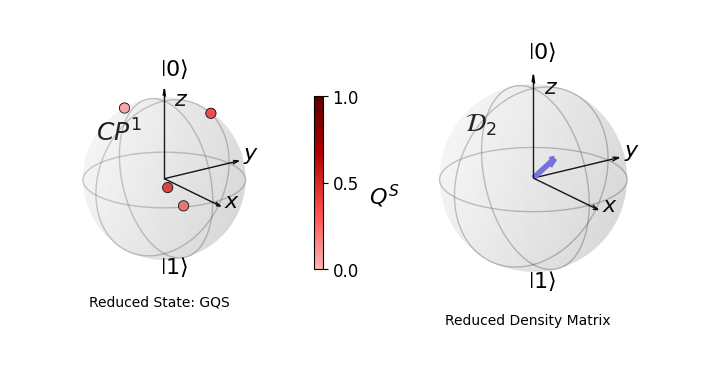

In [3]:
dhilbert = 2
nchain = 3
system_site = 0
psi = random_wavefunction(nchain)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)


Global State
(0.2888-0.1133j) |000>       + (-0.1429-0.2624j) |001>      + (0.0466-0.2164j) |010>       + (0.0884+0.2714j) |011>       +
(0.2744-0.1746j) |100>       + (0.0055-0.0021j) |101>       + (0.2092-0.2313j) |110>       + (0.6339-0.2812j) |111>      

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.2913        0.0560+0.0999j  
|1>         0.0560-0.0999j        0.7087      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 1
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 4



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(0.758-0.297j) |0> + (0.122-0.568j) |1>,0.145000
1,1,|01>,(-0.346-0.635j) |0> + (0.214+0.657j) |1>,0.171000
2,2,|10>,(0.609-0.387j) |0> + (0.464-0.513j) |1>,0.203000
3,3,|11>,(0.008-0.003j) |0> + (0.914-0.405j) |1>,0.481000


Reduced States Plot


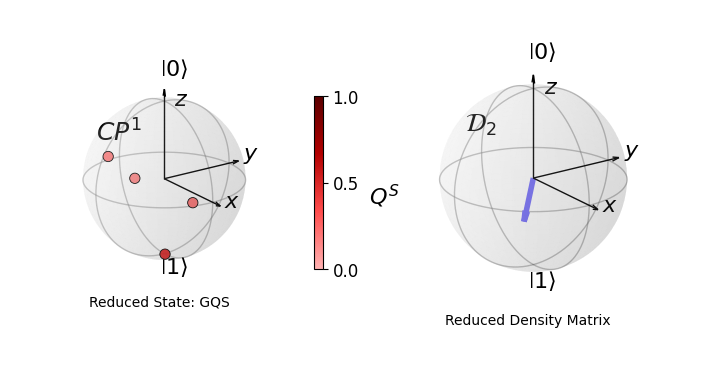

In [4]:
system_site = 1
psi = random_wavefunction(nchain)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)


Global State
(0.3119+0.1824j) |000>       + (0.2014+0.0272j) |001>       + (0.4002+0.2060j) |010>       + (-0.0809+0.1361j) |011>      +
(0.0309+0.2992j) |100>       + (-0.1526-0.0881j) |101>      + (-0.6070-0.2243j) |110>      + (0.2415+0.0441j) |111>      

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.8423       -0.1241-0.1132j  
|1>        -0.1241+0.1132j        0.1577      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 2
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 4



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(0.752+0.440j) |0> + (0.486+0.066j) |1>,0.172000
1,1,|01>,(0.839+0.432j) |0> + (-0.170+0.285j) |1>,0.228000
2,2,|10>,(0.089+0.858j) |0> + (-0.438-0.253j) |1>,0.122000
3,3,|11>,(-0.877-0.324j) |0> + (0.349+0.064j) |1>,0.479000


Reduced States Plot


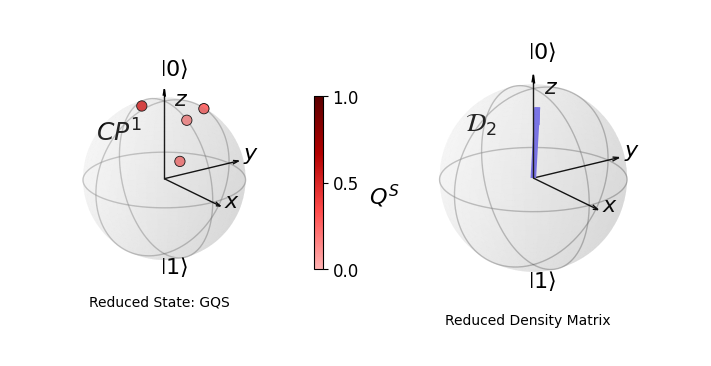

In [5]:
system_site = 2
psi = random_wavefunction(nchain)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)


Global State
(0.0225-0.3226j) |0000>      + (-0.1294+0.1217j) |0001>     + (0.1040-0.1861j) |0010>      + (0.1835-0.0840j) |0011>      +
(0.1467-0.0607j) |0100>      + (-0.0550+0.2817j) |0101>     + (-0.1129-0.3605j) |0110>     + (-0.1200+0.0486j) |0111>     +
(0.2883+0.0762j) |1000>      + (0.0830-0.0754j) |1001>      + (0.0874+0.0123j) |1010>      + (0.2238+0.1764j) |1011>      +
(0.1568+0.1403j) |1100>      + (-0.0780+0.0411j) |1101>     + (-0.0934+0.2306j) |1110>     + (-0.3606-0.2758j) |1111>    

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.4894       -0.0173-0.2038j  
|1>        -0.0173+0.2038j        0.5106      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 0
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 8



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|000>,(0.051-0.733j) |0> + (0.655+0.173j) |1>,0.194000
1,1,|001>,(-0.616+0.579j) |0> + (0.395-0.359j) |1>,0.044000
2,2,|010>,(0.451-0.807j) |0> + (0.379+0.053j) |1>,0.053000
3,3,|011>,(0.525-0.241j) |0> + (0.641+0.505j) |1>,0.122000
4,4,|100>,(0.557-0.230j) |0> + (0.595+0.532j) |1>,0.069000
5,5,|101>,(-0.183+0.938j) |0> + (-0.260+0.137j) |1>,0.090000
6,6,|110>,(-0.250-0.797j) |0> + (-0.207+0.510j) |1>,0.205000
7,7,|111>,(-0.254+0.103j) |0> + (-0.764-0.584j) |1>,0.223000


Reduced States Plot


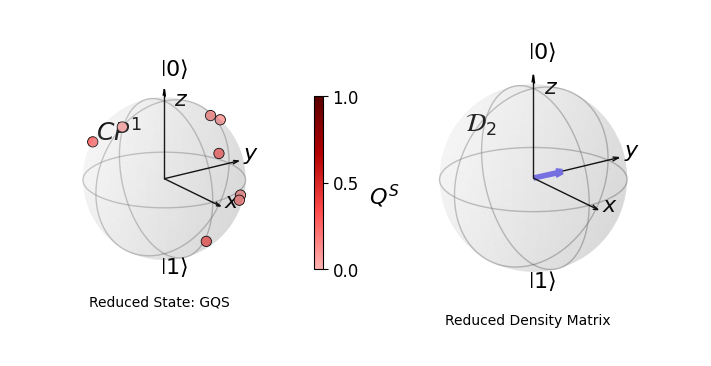

In [6]:
dhilbert = 2
nchain = 4
system_site = 0
psi = random_wavefunction(4)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)

Global State
(0.1664+0.0164j) |00000>     + (-0.0754+0.0457j) |00001>    + (0.0685-0.0086j) |00010>     + (-0.1045-0.0692j) |00011>    +
(0.0598-0.1344j) |00100>     + (-0.0107+0.0643j) |00101>    + (-0.1772-0.0322j) |00110>    + (0.1426+0.2448j) |00111>     +
(-0.0990-0.1704j) |01000>    + (-0.1272+0.0698j) |01001>    + (0.0079-0.0413j) |01010>     + (-0.0574+0.1386j) |01011>    +
(0.0649-0.0053j) |01100>     + (0.0904+0.1457j) |01101>     + (0.1036-0.1715j) |01110>     + (-0.1270-0.1680j) |01111>    +
(0.1797-0.3515j) |10000>     + (-0.0165+0.0309j) |10001>    + (0.1131-0.2543j) |10010>     + (0.0801+0.0726j) |10011>     +
(0.0696-0.1375j) |10100>     + (-0.0154-0.0189j) |10101>    + (0.0421-0.0222j) |10110>     + (0.0190+0.1472j) |10111>     +
(-0.2496-0.1167j) |11000>    + (-0.0597-0.2864j) |11001>    + (0.0826+0.1762j) |11010>     + (0.0055+0.0137j) |11011>     +
(-0.2339+0.0306j) |11100>    + (-0.0541+0.1042j) |11101>    + (-0.0703-0.0099j) |11110>    + (-0.1543+0.1007j) |11111> 

,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|0000>,(0.388+0.038j) |0> + (0.419-0.820j) |1>,0.184000
1,1,|0001>,(-0.795+0.482j) |0> + (-0.174+0.325j) |1>,0.009000
2,2,|0010>,(0.239-0.030j) |0> + (0.394-0.887j) |1>,0.082000
3,3,|0011>,(-0.631-0.418j) |0> + (0.484+0.439j) |1>,0.027000
4,4,|0100>,(0.281-0.631j) |0> + (0.327-0.645j) |1>,0.045000
5,5,|0101>,(-0.154+0.924j) |0> + (-0.221-0.272j) |1>,0.005000
6,6,|0110>,(-0.951-0.173j) |0> + (0.226-0.119j) |1>,0.035000
7,7,|0111>,(0.446+0.765j) |0> + (0.059+0.460j) |1>,0.102000
8,8,|1000>,(-0.292-0.503j) |0> + (-0.737-0.344j) |1>,0.115000
9,9,|1001>,(-0.389+0.214j) |0> + (-0.183-0.877j) |1>,0.107000


Reduced States Plot


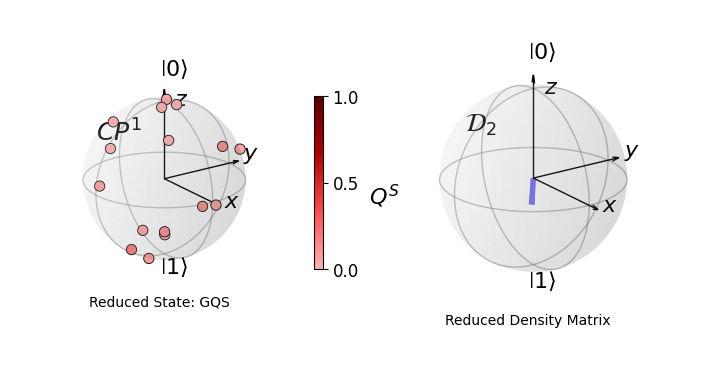

In [7]:
dhilbert = 2
nchain = 5
system_site = 0
psi = random_wavefunction(5)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)